<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.878 · Trabajo Final del Máster · Área 1 · Aula 1</p>
<p style="margin: 0; text-align:right;">20241 - Máster universitario en Ciencias de datos (<i>Data science</i>)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicaciones</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
    <strong>Estudiante:</strong> James Eward Humberstone Morales
</div>

 # Estrategia de agrupamiento combinada: K-Shape + K-Means

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Objetivo General:</strong>
    <ul>
        <li>Identificar patrones de comportamiento en las series temporales de ventas y caracterizar productos según sus dinámicas de venta y sus propiedades estadísticas.</li>    
    </ul>
    <p><strong>Clustering basado en forma temporal con K-Shape:</strong></p>
    <ul>
        <li>Permite agrupar los productos en función de la forma de su serie temporal de ventas diarias. Utiliza la <strong>correlación cruzada normalizada</strong> como métrica de similitud.</li>
        <li><strong>Ventajas:</strong> a) captura patrones recurrentes de comportamiento temporal, b) no requiere preprocesamiento complejo ni reducción de dimensiones y c) produce clusters de fácil visualización del centroide.</li>
        <li><strong>Utilidad</strong>: proporciona una agrupación inicial basada en la forma de venta, que se puede usar como una característica adicional en otros modelos.</li>
    </ul>
    <p><strong>Clustering K-Means basado en variables estadísticas y cluster de K-Shape:</strong></p>
    <ul>
        <li>Permite agrupar los productos con K-Means sobre el espacio reducido.</li>
        <li><strong>Ventaja:</strong> el clustering final integra la forma y la estructura de las series, permitiendo análisis más ricos y segmentación más fina..</li>
        <li><strong>Utilidad</strong>: es ideal para construir perfiles de producto más completos.</li>
    </ul>
</div>

In [1]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 6.8 MB/s eta 0:00:00a 0:00:01


In [2]:
# Carga de librerías
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import KShape
from tslearn.clustering import TimeSeriesKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# 1. Preprocesado de los datos

In [3]:
#Carga de los datos
df = pd.read_excel('/kaggle/input/tfm-result-eda/base_limpia_eda.xlsx')

In [4]:
aprovisionamiento = pd.read_excel('/kaggle/input/ciclo-de-aprovisionamiento/DatosCicloAprovisionamiento.xlsx')

# Calcular el ciclo de aprovisionamiento
aprovisionamiento["aprovisionamiento"] = aprovisionamiento["diasEntrePedidos"] + aprovisionamiento["diasLeadtime"]

# Unir aprovisionamiento  a la base
df = pd.merge(
    df,
    aprovisionamiento,
    on=['producto'],
    how='left' 
)

In [5]:
print(f"Número de registros: {df.shape[0]}")
print("Tipos de variables:")
print(df.dtypes)

Número de registros: 654408
Tipos de variables:
producto                      int64
idSecuencia          datetime64[ns]
bolOpen                       int64
bolHoliday                    int64
year                          int64
month                         int64
day                           int64
day_of_week                   int64
week_of_year                  int64
week_of_month                 int64
bolPromotion                  int64
udsVenta                      int64
median_venta                  int64
cv                          float64
outlier_rate                float64
diasEntrePedidos              int64
diasLeadtime                  int64
aprovisionamiento             int64
dtype: object


## 1.1. Preparar los datos para aplicar K-Shape

In [6]:
# Verificar si exiten filas duplicadas por producto y fecha
df.groupby(['producto', 'idSecuencia']).size().reset_index(name='counts').query('counts > 1')

,producto,idSecuencia,counts


In [7]:
# Pivotear: filas = productos, columnas = fechas
ventas_por_producto = df.pivot(index='producto', columns='idSecuencia', values='udsVenta')

In [8]:
ventas_por_producto.shape

(894, 732)

In [9]:
ventas_por_producto.head()

idSecuencia,2022-11-05,2022-11-06,2022-11-07,2022-11-08,2022-11-09,2022-11-10,2022-11-11,2022-11-12,2022-11-13,2022-11-14,...,2024-10-27,2024-10-28,2024-10-29,2024-10-30,2024-10-31,2024-11-01,2024-11-02,2024-11-03,2024-11-04,2024-11-05
producto,,,,,,,,,,,,,,,,,,,,,
1,7,0,12,28,14,26,24,31,0,12,...,0,7,7,7,2,2,9,0,19,9
2,7,0,5,24,12,19,5,14,0,9,...,0,2,9,5,7,0,16,0,0,2
3,19,0,7,0,5,12,21,12,0,19,...,0,5,9,12,12,0,2,0,2,5
4,2,0,12,5,5,2,12,5,0,12,...,0,0,0,0,0,0,0,0,7,9
5,7,0,14,16,7,7,14,12,0,2,...,0,5,9,0,0,0,0,0,0,0


##  1.2. Escalar los datos

In [10]:
# Convertir a array de 3 dimensiones: (n_series, n_timestamps, 1)
X = ventas_por_producto.values.reshape(ventas_por_producto.shape[0], ventas_por_producto.shape[1], 1)

# Escalar los datos
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X)

# 2. Aplicar K-Shape

## 2.1. Estimar el número óptimos de cluster

In [11]:
sil_scores = []
range_k = range(2, 11)

for k in range_k:
    print(f"Probando k = {k}...")
    ks = KShape(n_clusters=k, random_state=42)
    y_pred = ks.fit_predict(X_scaled)
    
    X_flat = X_scaled.reshape((X_scaled.shape[0], -1))
    score = silhouette_score(X_flat, y_pred)
    
    sil_scores.append((k, score))
    print(f"Silhouette score para k = {k}: {score:.4f}")

Probando k = 2...
Silhouette score para k = 2: 0.0127
Probando k = 3...
Silhouette score para k = 3: 0.0079
Probando k = 4...
Silhouette score para k = 4: 0.0039
Probando k = 5...
Silhouette score para k = 5: 0.0037
Probando k = 6...
Silhouette score para k = 6: 0.0033
Probando k = 7...
Silhouette score para k = 7: 0.0032
Probando k = 8...
Silhouette score para k = 8: 0.0026
Probando k = 9...
Silhouette score para k = 9: 0.0032
Probando k = 10...
Silhouette score para k = 10: 0.0031


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observaciones:</strong>
    <ul>
        <li>El <strong>silhouette score</strong> es una métrica clave para evaluar la calidad de un clustering y utiliza la <strong>distancia euclidiana</strong> en su cálculo.</li>
        <li><strong>K-Shape:</strong> no agrupa por distancia euclidiana, sino por similitud de forma, es decir, utiliza correlación cruzada normalizada para su cálculo.</li>
        <li>Por lo tanto, hay un desajuste entre la métrica usada para agrupar y la usada para evaluar. Paparrizos & Gravano (2015), reconocen que K-Shape no es bien evaluado con silhouette score tradicional, por lo que <strong>la recomendación es evaluar visualmente y observar la calidad de los centroides y la coherencia de las formas.</strong></li>
        <li>Apesar que los resultdos de <strong>silhouette score</strong> son bajas se utiliza para determinar el k óptimo y luego realizar la evaluación de forma visual. </li>
    </ul>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
    <p><strong>Conclusión.</strong> El número óptimo de clusteres (k) es 2</p>
</div>

## 2.2 Ejecutar K-shape con K=2

In [12]:
# Clustering con k = 2
kshape_model = KShape(n_clusters=2, random_state=42)
cluster_labels = kshape_model.fit_predict(X_scaled)

# Centros de los clusters
centroides = kshape_model.cluster_centers_

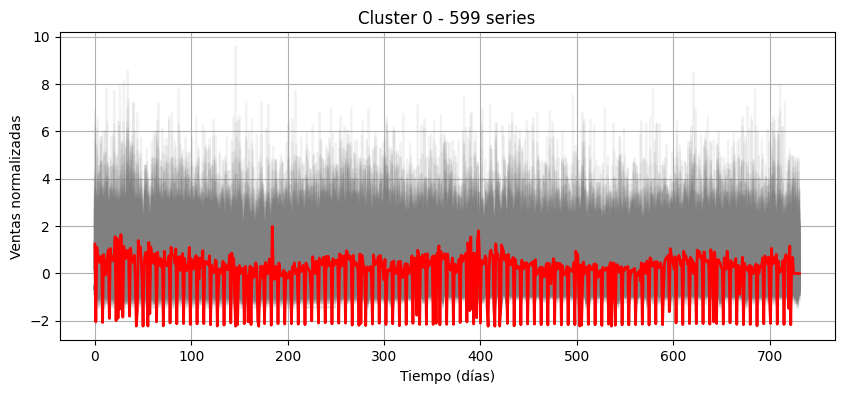

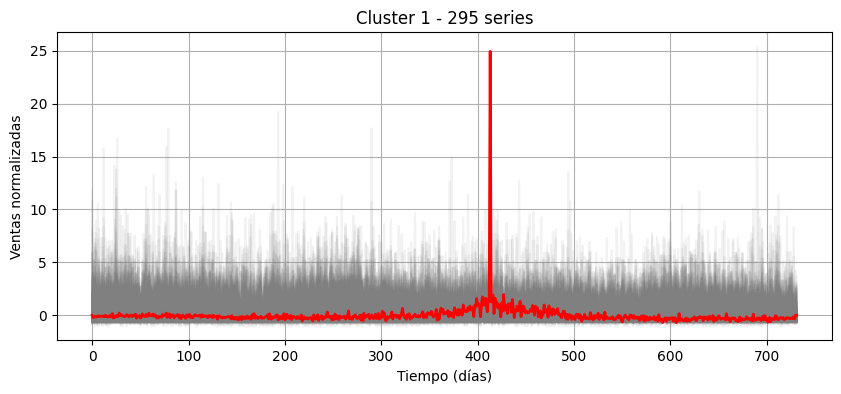

In [13]:
for cluster_id in range(2):
    plt.figure(figsize=(10, 4))
    for series in X_scaled[cluster_labels == cluster_id]:
        plt.plot(series.ravel(), color='gray', alpha=0.1)
    
    plt.plot(centroides[cluster_id].ravel(), color='red', linewidth=2)
    plt.title(f"Cluster {cluster_id} - {sum(cluster_labels == cluster_id)} series")
    plt.xlabel("Tiempo (días)")
    plt.ylabel("Ventas normalizadas")
    plt.grid(True)
    plt.savefig(f'Cluster {cluster_id}.png')
    plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observaciones:</strong>
    <p><strong>Cluster 0:</strong></p>
    <ul>
        <li>El centroide (línea roja) presenta un patrón periódico. Además, oscila en torno a un valor constante, con picos regulares a lo largo de toda la serie.</li>
        <li><strong>Interpretación:</strong> Este cluster agrupa productos con demanda regular, continua y estable. En la teoría de inventario y pronóstico, estos productos son considerados más fáciles de modelar y prever.</li>
        <li><strong>Conclusión</strong>: Este grupo representa productos regulares.</li>
    </ul>
    <p><strong>Cluster 1:</strong></p>
    <ul>
        <li>El centroide tiene una forma clara de pico abrupto cerca del día 400 y el resto del tiempo las ventas son bajas. Por lo que este patrón no es periódico ni constante, sino marcado por un evento puntual.</li>
        <li><strong>Interpretación:</strong> Este cluster agrupa productos cuya venta es impulsada por eventos específicos como lanzamientos y promociones. En teoría de demanda, esto se asocia con productos irregulares o intermitentes, donde la predicción es más desafiante.</li>
        <li><strong>Conclusión</strong>: Este grupo representa productos irregulares o de difícil previsión.</li>
    </ul>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
    <strong>Conclusión:</strong>
    <p>El algoritmo K-Shape ha segmentado claramente los productos en dos grupos diferenciados:</p>
    <ul>
        <li><strong>Cluster 0:</strong> productos regulares, con demanda constante y cíclica.</li>
        <li><strong>Cluster 1</strong>: productos irregulares, con picos puntuales y mayor variabilidad.</li>
    </ul>
</div>

## 2.3 Guardar los resultados

In [16]:
# Crear un DataFrame con producto y su cluster asignado
df_clusters = pd.DataFrame({
    'producto': ventas_por_producto.index,
    'cluster_kshape': cluster_labels
})

# Unir etiquetas de cluster al dataframe original
df_segmentado = df.merge(df_clusters, on='producto', how='left')

# quitar columnas diasEntrePedidos y diasLeadTime
df_segmentado.drop(columns=['diasEntrePedidos', 'diasLeadtime' ], inplace=True)

In [17]:
df_segmentado.head()

,producto,idSecuencia,bolOpen,bolHoliday,year,month,day,day_of_week,week_of_year,week_of_month,bolPromotion,udsVenta,median_venta,cv,outlier_rate,aprovisionamiento,cluster_kshape
0,1,2022-11-05,1,0,2022,11,5,5,44,1,1,7,7,0.844324,0.015027,29,0
1,1,2022-11-06,0,1,2022,11,6,6,44,1,1,0,7,0.844324,0.015027,29,0
2,1,2022-11-07,1,0,2022,11,7,0,45,2,1,12,7,0.844324,0.015027,29,0
3,1,2022-11-08,1,0,2022,11,8,1,45,2,1,28,7,0.844324,0.015027,29,0
4,1,2022-11-09,1,0,2022,11,9,2,45,2,1,14,7,0.844324,0.015027,29,0


In [18]:
# Exportar a Excel
df_segmentado.to_excel('base_y_kshape.xlsx', index=False)

# 3. Aplicar K-Means sobre los productos irregulares (Cluster 1)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <p>Los productos regulares (cluster 0) tienen un comportamiento bien definido y predecible. Aplicar más segmentación sobre ellos puede generar subdivisiones que no aporten mucho valor. Sin embargo, tiene mucho más valor profundizar en los subgrupos de los productos irregular.</p>
</div>

In [19]:
#Carga de los datos
df_segmentado = pd.read_excel('/kaggle/working/base_y_kshape.xlsx')

In [38]:
# Filtrar productos del cluster 1 (irregulares)
df_irregulares = df_segmentado[df_segmentado['cluster_kshape'] == 1].copy()

# Agrupar por producto y tomar la primera ocurrencia
df_productos = df_irregulares.groupby("producto")[["median_venta", "cv", "outlier_rate", "cluster_kshape"]].first().reset_index()

In [41]:
# Variables a usar para clustering
X = df_productos[["median_venta", "cv", "outlier_rate"]]

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [40]:
# Mostrar la varianza explicada
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

Varianza explicada por cada componente:
[0.41023977 0.29871841]


##  3.1 Estimar el número óptimo de cluster

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <p>Para determinar el k óptimo se utilizará el <strong>método del codo y el silhouette score</strong>.</p>
</div>

In [42]:
sil_scores = []
inertias = []
range_k = range(2, 11)

for k in range_k:
    print(f"Probando k = {k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    sil = silhouette_score(X_pca, labels)
    sil_scores.append(sil)
    inertias.append(kmeans.inertia_)

    print(f"k={k} -> Silhouette: {sil:.4f}, Inertia: {kmeans.inertia_:.2f}")

Probando k = 2...
k=2 -> Silhouette: 0.6602, Inertia: 340.66
Probando k = 3...
k=3 -> Silhouette: 0.6900, Inertia: 141.02
Probando k = 4...
k=4 -> Silhouette: 0.7306, Inertia: 63.10
Probando k = 5...
k=5 -> Silhouette: 0.6834, Inertia: 30.49
Probando k = 6...
k=6 -> Silhouette: 0.6704, Inertia: 23.35
Probando k = 7...
k=7 -> Silhouette: 0.5105, Inertia: 19.34
Probando k = 8...
k=8 -> Silhouette: 0.5084, Inertia: 15.19
Probando k = 9...
k=9 -> Silhouette: 0.4751, Inertia: 11.85
Probando k = 10...
k=10 -> Silhouette: 0.4828, Inertia: 10.10


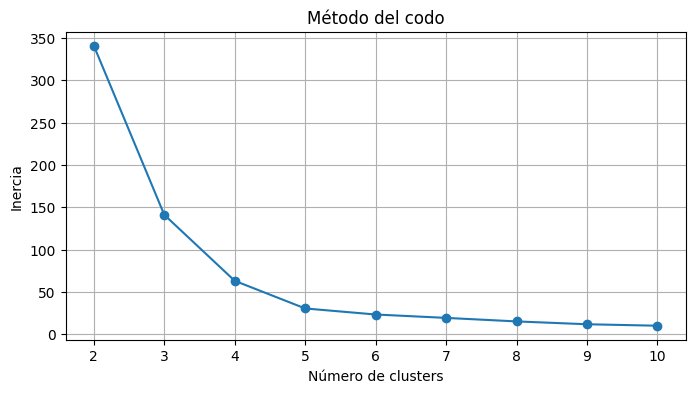

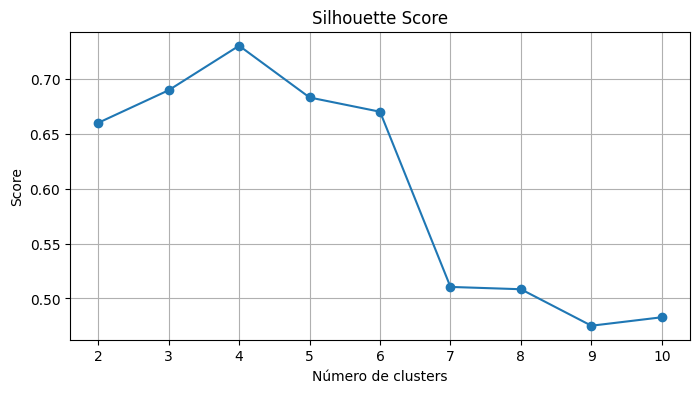

In [43]:
# Gráficar Elbow (codo)
plt.figure(figsize=(8, 4))
plt.plot(range_k, inertias, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

# Gráficar Silhouette
plt.figure(figsize=(8, 4))
plt.plot(range_k, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Número de clusters")
plt.ylabel("Score")
plt.grid(True)
plt.show()


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observaciones:</strong>
    <ul>
        <li><strong>El método del codo:</strong> nos recomienda que 4 clusteres, ya que se observa que apartir de es número cambia drásticamente la pendiente.</li>
        <li>El <strong>silhouette score:</strong> también nos sugiere que el número óptimo es 4, ya que presenta el valor más alto. Adémas, <strong>el valor de 0.7306 implica un clustering fuerte</strong>, es decir, grupos bien separados y compactos.</li>
        <li><strong>Conslusión:</strong> El número óptimo es 4 clusteres</li>
    </ul>
</div>

## 3.2 Ejecutar K-Means con k = 4

In [44]:
# Modelo final con k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_pca)

# Añadir etiquetas al dataframe
df_productos["cluster_kmeans"] = labels_final


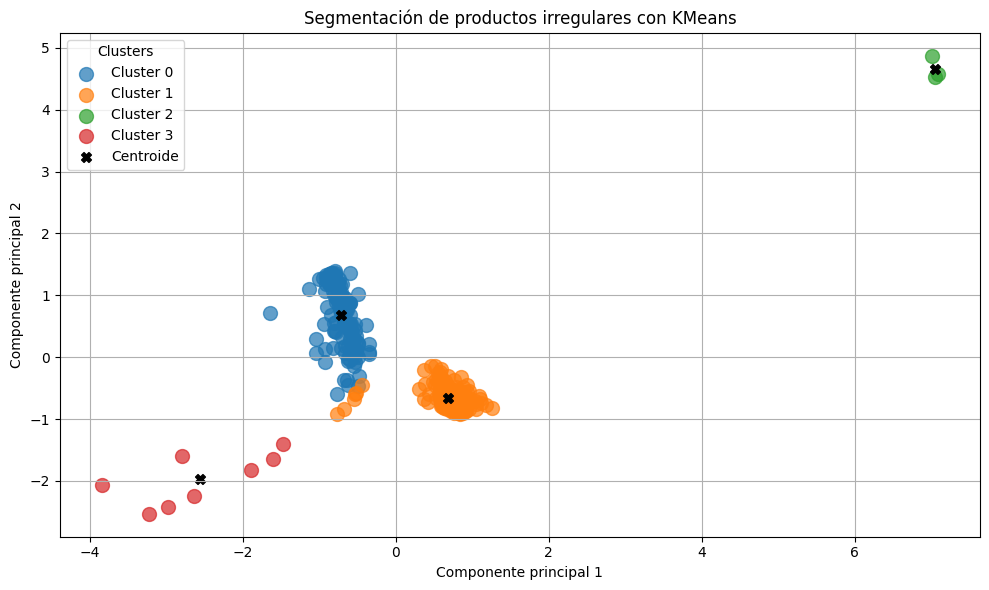

In [45]:
# Obtener centroides en el espacio PCA
centroides_pca = kmeans_final.cluster_centers_

# Obtener lista de clusters únicos ordenados
unique_clusters = np.unique(labels_final)
n_clusters = len(unique_clusters)

# Generar paleta de colores
colormap = plt.colormaps.get_cmap('tab10')
colors = [colormap(i) for i in range(n_clusters)]

# Crear figura
plt.figure(figsize=(10, 6))

# Dibujar puntos por cluster
for i, cluster_id in enumerate(unique_clusters):
    mask = labels_final == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                color=colors[i], 
                label=f'Cluster {cluster_id}', 
                s=100, alpha=0.7)

# Añadir centroides
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1], 
            c='black', s=50, marker='X', label='Centroide')


plt.legend(title="Clusters", loc='best')
plt.title("Segmentación de productos irregulares con KMeans")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.tight_layout()
plt.savefig('Cluster de productos irregulares.png')
plt.show()

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <ul>
        <li>Se observa adecuadamente los cuatro grupos.</li>
    </ul>
</div>

In [46]:
# Muestra de los datos
df_productos.head()

,producto,median_venta,cv,outlier_rate,cluster_kshape,cluster_kmeans
0,25,2,0.987961,0.036885,1,2
1,38,0,2.036619,0.019126,1,1
2,52,0,1.422424,0.017760,1,1
3,61,2,1.145222,0.010929,1,2
4,95,0,1.879742,0.062842,1,1


## 3.3 Guardar los resultados

In [47]:
df_segmentado = df_segmentado.merge(
    df_productos[['producto', 'cluster_kmeans']],
    on='producto',
    how='left'
)

df_segmentado['cluster_kmeans'] = df_segmentado['cluster_kmeans'].fillna(-1).astype(int)

In [48]:
# Exportar a Excel
df_segmentado.to_excel('base_kshape-kmeans.xlsx', index=False)

## 3.4 Describir perfiles de los clusters

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <p>Para entener mejor los clusters generados por K-Means. Se utilizará las características: <strong>median_venta, cv y outlier_rate</strong> para describir el perfil de cada grupo.</p>
</div>

In [49]:
# Filtrar productos irregulares ya segmentados
df_irregulares_unicos = df_segmentado[df_segmentado["cluster_kshape"] == 1].drop_duplicates(subset="producto")

# Resumen estadístico
resumen_clusters = df_irregulares_unicos.groupby("cluster_kmeans")[["median_venta", "cv", "outlier_rate"]].agg(['mean', 'std', 'count'])

# Aplanar columnas
resumen_clusters.columns = ['_'.join(col) for col in resumen_clusters.columns]
resumen_clusters = resumen_clusters.reset_index()
resumen_clusters.drop(columns=['cv_count', 'outlier_rate_count'], inplace=True)
resumen_clusters.rename(columns={'median_venta_count': 'count'}, inplace=True)
# Mostrar resultado
resumen_clusters


,cluster_kmeans,median_venta_mean,median_venta_std,count,cv_mean,cv_std,outlier_rate_mean,outlier_rate_std
0,0,0.0,0.0,140,2.568529,0.397280,0.188544,0.043273
1,1,0.0,0.0,144,1.938876,0.406857,0.033242,0.019393
2,2,2.0,0.0,3,1.127735,0.131903,0.018670,0.015834
3,3,0.0,0.0,8,7.400950,1.381811,0.037568,0.025020


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observaciones:</strong>
    <ul>
        <li><strong>Cluster 0:</strong> Productos con ventas irregulares (mediana = 0), con alta variablidad (cv_mean = 2.56) y bastantes picos atípicos (outlier_rate = 0.19). <strong>Perfil</strong>: Irregulares con picos extremos (alta outlier_rate).</li>
        <li><strong>Cluster 1:</strong> Productos con ventas irregulares (mediana = 0), con alta variablidad (cv_mean = 1.93) y muy pocos picos atípicos (outlier_rate = 0.03). <strong>Perfil</strong>: Irregulares sin picos extremos.</li>
        <li><strong>Cluster 2:</strong> Productos con ventas regulares (mediana = 2), con variablidad moderada (cv_mean = 1.12) y muy pocos atípicos (outlier_rate = 0.018). <strong>Perfil</strong>: Casi regulares, ventas constantes y baja variación.</li>
        <li><strong>Cluster 3:</strong> Productos con ventas irregulares (mediana = 0), con altísima variablidad (cv_mean = 7.54) y pocos picos atípicos (outlier_rate = 0.03). <strong>Perfil</strong>: Irregulares con picos extremos (altísima cv).</li>
    </ul>
</div>

# 4. Series representativas de cada cluster

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Objetivo:</strong>
    <ul>
        <li>El objetivo de este apartado es desarrollar modelos de predicción de la demanda más generalizables, reduciendo la complejidad computacional al entrenar modelos sobre series representativas por clúster en lugar de por producto individual.</li>
    </ul>
</div>

In [51]:
#Carga de los datos
df = pd.read_excel('/kaggle/working/base_kshape-kmeans.xlsx')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654408 entries, 0 to 654407
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   producto           654408 non-null  int64         
 1   idSecuencia        654408 non-null  datetime64[ns]
 2   bolOpen            654408 non-null  int64         
 3   bolHoliday         654408 non-null  int64         
 4   year               654408 non-null  int64         
 5   month              654408 non-null  int64         
 6   day                654408 non-null  int64         
 7   day_of_week        654408 non-null  int64         
 8   week_of_year       654408 non-null  int64         
 9   week_of_month      654408 non-null  int64         
 10  bolPromotion       654408 non-null  int64         
 11  udsVenta           654408 non-null  int64         
 12  median_venta       654408 non-null  int64         
 13  cv                 654408 non-null  float64 

In [53]:

df_cluster_regulares = df[df['cluster_kshape'] == 0].copy()

# Agregación por fecha para obtener una serie temporal representativa
serie_regulares = df_cluster_regulares.groupby('idSecuencia').agg({
    'udsVenta': 'median',             # mediana de ventas como valor representativo
    'bolOpen': 'mean',                # proporción de apertura
    'bolHoliday': 'mean',             # proporción de días festivos
    'year': 'first',                  # año (todos iguales por fecha)
    'month': 'first',                 # mes del año
    'day': 'first',                   # dia del mes
    'day_of_week': 'first',           # día de la semana 
    'week_of_year': 'first',          # semana del año
    'week_of_month': 'first',         # semana del mes
    'bolPromotion': 'mean',           # proporción de productos en promoción
    'median_venta': 'median',         # mediana de la venta
    'cv': 'median',                   # mediana del coeficiente de variación
    'outlier_rate': 'median',         # mediana de la tasa de atípicos
    'aprovisionamiento': 'median',    # mediana del aprovisionamiento
    'cluster_kshape': 'first',        # cluster 0
    'cluster_kmeans': 'first'
}).reset_index()

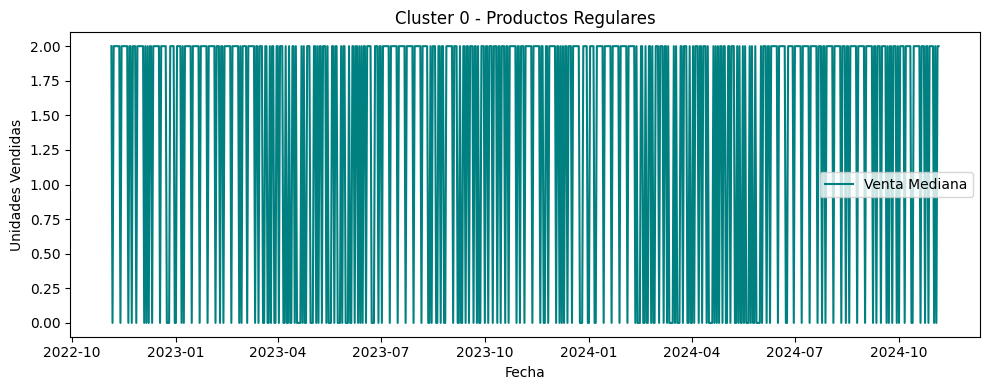

In [54]:
# Figura 1: Serie regular
fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(serie_regulares['idSecuencia'], serie_regulares['udsVenta'], label='Venta Mediana', color='teal')
ax1.set_title('Cluster 0 - Productos Regulares')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Unidades Vendidas')
ax1.legend()
plt.tight_layout()
plt.savefig('Representación de la serire regular.png')
plt.show()

In [55]:
# Guardar la serie regular en CSV
serie_regulares.to_csv('serie_cluster_0_regulares.csv', index=False)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <ul>
        <li>El clúster 0, corresponde a productos con comportamiento regular, por lo que se construyó una serie temporal representativa utilizando la mediana diaria de unidades vendidas entre todos los productos del grupo. Esta medida permite capturar el comportamiento central del clúster, evitando que casos extremos individuales distorsionen la señal general. Si bien algunos productos pueden experimentar días sin venta o picos puntuales, la mediana los suaviza.</li>
    </ul>
</div>

In [56]:
series_irregulares = {}

for kmeans_cluster in range(4):
    df_cluster_irregular = df[
        (df['cluster_kshape'] == 1) &
        (df['cluster_kmeans'] == kmeans_cluster)
    ].copy()

    # Crear columna booleana de actividad de venta
    df_cluster_irregular['venta_binaria'] = df_cluster_irregular['udsVenta'] > 0

    # Frecuencia de ventas: % de productos que vendieron algo ese día
    serie_frecuencia = df_cluster_irregular.groupby('idSecuencia')['venta_binaria'].mean()

    # Magnitud de ventas: media de ventas entre los productos que vendieron algo (> 0)
    df_con_venta = df_cluster_irregular[df_cluster_irregular['udsVenta'] > 0]
    serie_magnitud = df_con_venta.groupby('idSecuencia')['udsVenta'].mean()

    # Variables exógenas agregadas
    exog_vars = df_cluster_irregular.groupby('idSecuencia').agg({
        'bolOpen': 'mean',                # proporción de apertura
        'bolHoliday': 'mean',             # proporción de días festivos
        'year': 'first',                  # año (todos iguales por fecha)
        'month': 'first',                 # mes del año
        'day': 'first',                   # dia del mes
        'day_of_week': 'first',           # día de la semana 
        'week_of_year': 'first',          # semana del año
        'week_of_month': 'first',         # semana del mes
        'bolPromotion': 'mean',           # proporción de productos en promoción
        'median_venta': 'median',         # mediana de la venta
        'cv': 'median',                   # mediana del coeficiente de variación
        'outlier_rate': 'median',         # mediana de la tasa de atípicos
        'aprovisionamiento': 'median',    # mediana del aprovisionamiento
        'cluster_kshape': 'first',        # cluster 0
        'cluster_kmeans': 'first'
    })

    # Unir todo
    serie_irregular = pd.concat([serie_frecuencia, serie_magnitud, exog_vars], axis=1).reset_index()
    serie_irregular.columns = ['idSecuencia', 'venta_frecuencia', 'venta_magnitud'] + list(exog_vars.columns)

    # Rellenar valores NaN en venta_magnitud con 0 (días sin ventas)
    serie_irregular['venta_magnitud'] = serie_irregular['venta_magnitud'].fillna(0)

    # Guardar
    series_irregulares[f'cluster_1_{kmeans_cluster}'] = serie_irregular

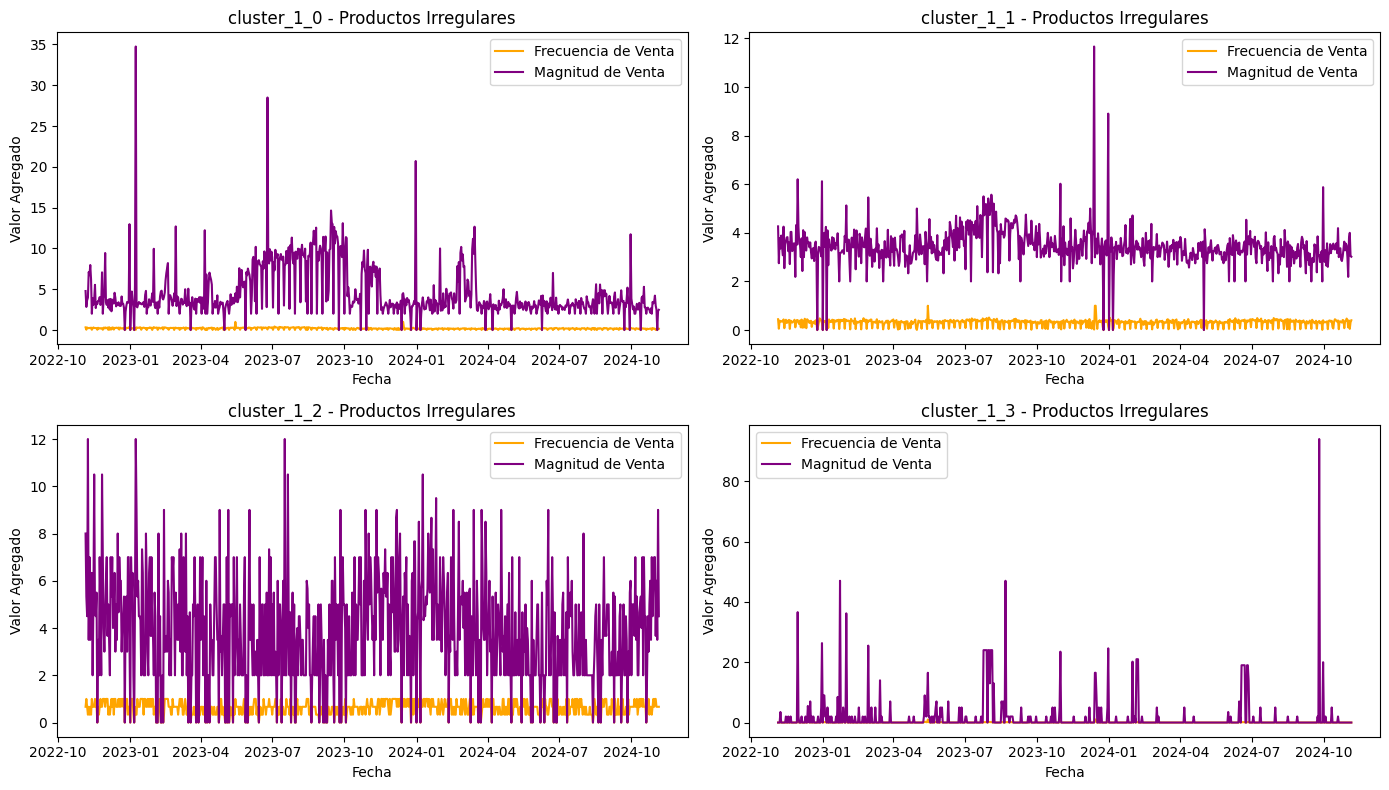

In [57]:
# Figura 2: Series irregulares
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8))
axes2 = axes2.flatten()

for i, (cluster_name, df_cluster) in enumerate(series_irregulares.items()):
    ax = axes2[i]
    ax.plot(df_cluster['idSecuencia'], df_cluster['venta_frecuencia'], label='Frecuencia de Venta', color='orange')
    ax.plot(df_cluster['idSecuencia'], df_cluster['venta_magnitud'], label='Magnitud de Venta', color='purple')
    ax.set_title(f'{cluster_name} - Productos Irregulares')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Valor Agregado')
    ax.legend()

plt.tight_layout()
plt.savefig('Represenación de series irregulares.png')
plt.show()

In [58]:
# Guardar cada serie irregular en un archivo separado
paths_irregulares = {}
for nombre_cluster, df_cluster in series_irregulares.items():
    df_cluster.to_csv(f"serie_{nombre_cluster}_irregular.csv", index=False)

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
    <strong>Observación:</strong>
    <ul>
        <li>Para representar los productos con comportamiento irregular, se construyeron dos series agregadas por clúster: la frecuencia de venta diaria —que indica el porcentaje de productos activos— y la magnitud promedio de venta cuando ocurre. La primera refleja la probabilidad de activación del clúster, mientras que la segunda refleja la intensidad de la demanda cuando esta se manifiesta. Esta separación permite modelar con mayor precisión los patrones discontinuos y dispersos característicos de estos productos.</li>
    </ul>
</div>

<div style="background-color: #d5f5e3; border-color: #82e0aa; border-left: 5px solid #82e0aa; padding: 0.5em;">
    <strong>Conclusiones:</strong>
    <p>Los algoritmos K-Shape y K-Means han permito agrupar los productos en cinco cluster. Entre los beneficios obtenidos están</p>
    <ul>
        <li><strong>Modelado por similitud:</strong> cada clúster agrupa productos con patrones comparables, haciendo más fácil el aprendizaje.</li>
        <li><strong>Facilita los análisis comparativos:</strong> al mantener la misma estructura por clúster, es posible evaluar de forma clara la efectividad de diferentes arquitecturas híbridas.</li>
        <li><strong>Reutilización del modelo:</strong> un modelo entrenado por clúster puede aplicarse directamente a todos los productos del grupo, facilitando escalabilidad.</li>
    </ul>
</div>